<a href="https://colab.research.google.com/github/springboardmentor1000-del/RideWise-BikeDemandPrediction2/blob/Kavyasri/KAVYA_FEATURE_SELECTION_DEC_18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import pandas as pd
import numpy as np


In [16]:
day = pd.read_csv("/content/day[1].csv")
hour = pd.read_csv("/content/hour[1].csv")


In [17]:
day_clean = day.drop(columns=["instant"])
hour_clean = hour.drop(columns=["instant"])


In [18]:
day_clean["comfort_index"] = day_clean["temp"] * (1 - day_clean["hum"])
hour_clean["comfort_index"] = hour_clean["temp"] * (1 - hour_clean["hum"])


In [19]:
day_clean["wind_chill_effect"] = day_clean["windspeed"] * (1 - day_clean["temp"])
hour_clean["wind_chill_effect"] = hour_clean["windspeed"] * (1 - hour_clean["temp"])


In [20]:
weather_map = {1: 0, 2: 1, 3: 2, 4: 3}

day_clean["weather_severity"] = day_clean["weathersit"].map(weather_map)
hour_clean["weather_severity"] = hour_clean["weathersit"].map(weather_map)


In [21]:
day_clean["is_weekend"] = day_clean["weekday"].apply(
    lambda x: 1 if x in [0, 6] else 0
)
hour_clean["is_weekend"] = hour_clean["weekday"].apply(
    lambda x: 1 if x in [0, 6] else 0
)


In [22]:
hour_clean["is_peak_hour"] = hour_clean["hr"].apply(
    lambda x: 1 if (7 <= x <= 9 or 17 <= x <= 19) else 0
)


In [23]:
def time_block(hr):
    if 5 <= hr <= 11:
        return "Morning"
    elif 12 <= hr <= 16:
        return "Afternoon"
    elif 17 <= hr <= 21:
        return "Evening"
    else:
        return "Night"

hour_clean["time_block"] = hour_clean["hr"].apply(time_block)
hour_clean = pd.get_dummies(hour_clean, columns=["time_block"], drop_first=True)


In [24]:
hour_agg = hour.groupby("dteday").agg(
    avg_hourly_cnt=("cnt", "mean"),
    max_hourly_cnt=("cnt", "max"),
    morning_commute=("cnt", lambda x: x.iloc[7:10].mean()),
    evening_commute=("cnt", lambda x: x.iloc[17:20].mean())
).reset_index()


In [25]:
day_enhanced = day_clean.merge(hour_agg, on="dteday", how="left")



In [26]:
drop_cols = [
    "dteday",
    "weathersit",   # replaced by weather_severity
    "weekday"       # replaced by is_weekend
]

day_enhanced = day_enhanced.drop(columns=drop_cols)
hour_clean = hour_clean.drop(columns=["dteday", "weathersit", "weekday"])


In [27]:
day_features = [
    "season", "yr", "mnth", "workingday",
    "is_weekend", "temp", "comfort_index",
    "wind_chill_effect", "weather_severity",
    "avg_hourly_cnt", "morning_commute", "evening_commute"
]

X_day = day_enhanced[day_features]
y_day = day_enhanced["cnt"]


In [28]:
hour_features = [
    "hr", "is_peak_hour", "season", "workingday",
    "is_weekend", "temp", "comfort_index",
    "wind_chill_effect", "weather_severity",
    "hum", "windspeed"
] + [col for col in hour_clean.columns if col.startswith("time_block_")]

X_hour = hour_clean[hour_features]
y_hour = hour_clean["cnt"]


In [29]:
print("Day features:", X_day.columns.tolist())
print("Hour features:", X_hour.columns.tolist())


Day features: ['season', 'yr', 'mnth', 'workingday', 'is_weekend', 'temp', 'comfort_index', 'wind_chill_effect', 'weather_severity', 'avg_hourly_cnt', 'morning_commute', 'evening_commute']
Hour features: ['hr', 'is_peak_hour', 'season', 'workingday', 'is_weekend', 'temp', 'comfort_index', 'wind_chill_effect', 'weather_severity', 'hum', 'windspeed', 'time_block_Evening', 'time_block_Morning', 'time_block_Night']


In [35]:

# Correlation-based feature impact (DAY)
day_feature_impact = (
    day_enhanced[X_day.columns.tolist() + ["cnt"]]
    .corr(numeric_only=True)["cnt"]
    .drop("cnt")
    .abs()
    .sort_values(ascending=False)
)

print("DAY FEATURE IMPACT (High → Low):")
print(day_feature_impact)



DAY FEATURE IMPACT (High → Low):
avg_hourly_cnt       0.998683
evening_commute      0.891960
morning_commute      0.680823
temp                 0.627494
yr                   0.566710
comfort_index        0.559956
wind_chill_effect    0.526257
season               0.406100
weather_severity     0.297391
mnth                 0.279977
workingday           0.061156
is_weekend           0.037604
Name: cnt, dtype: float64


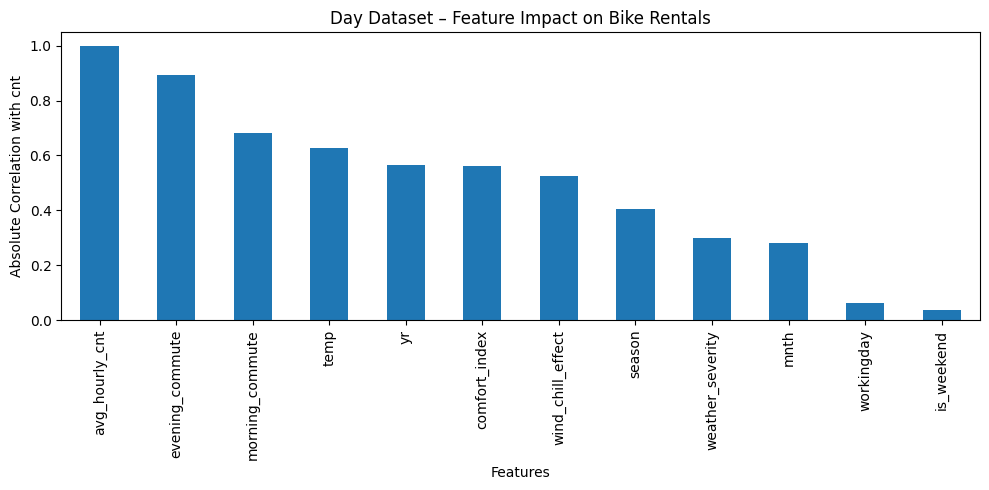

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
day_feature_impact.plot(kind="bar")
plt.title("Day Dataset – Feature Impact on Bike Rentals")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation with cnt")
plt.tight_layout()
plt.show()


In [37]:
# Correlation-based feature impact (HOUR)
hour_feature_impact = (
    hour_clean[X_hour.columns.tolist() + ["cnt"]]
    .corr(numeric_only=True)["cnt"]
    .drop("cnt")
    .abs()
    .sort_values(ascending=False)
)

print("HOUR FEATURE IMPACT (High → Low):")
print(hour_feature_impact)


HOUR FEATURE IMPACT (High → Low):
comfort_index         0.502766
time_block_Night      0.488953
is_peak_hour          0.453926
temp                  0.404772
hr                    0.394071
time_block_Evening    0.368986
hum                   0.322911
season                0.178056
weather_severity      0.142426
wind_chill_effect     0.136189
windspeed             0.093234
workingday            0.030284
time_block_Morning    0.028131
is_weekend            0.019699
Name: cnt, dtype: float64


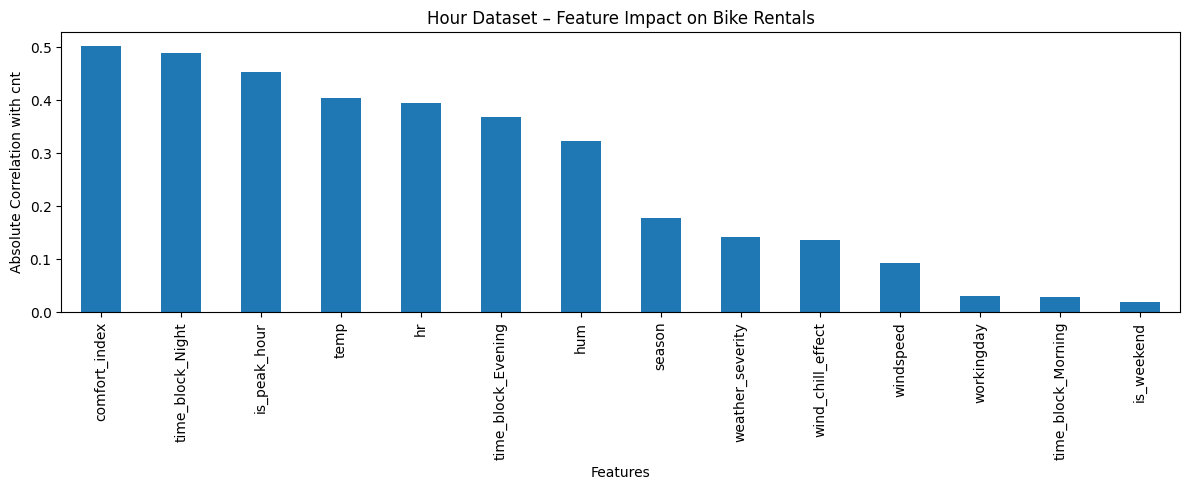

In [38]:
plt.figure(figsize=(12,5))
hour_feature_impact.plot(kind="bar")
plt.title("Hour Dataset – Feature Impact on Bike Rentals")
plt.xlabel("Features")
plt.ylabel("Absolute Correlation with cnt")
plt.tight_layout()
plt.show()
